# Geospatial Data Exploration

This notebook explains what geospatial information exists in the Grupo Bimbo dataset after the preparation pipeline, what is inferred, and where the weak spots are.

The key distinction throughout the notebook is:

- `nominatim`: a town-level coordinate returned by OpenStreetMap Nominatim.
- `state_centroid`: a fallback coordinate placed at the approximate state center because town-level geocoding was missing or failed.

State-centroid rows are usable for coarse regional modeling, but they should not be interpreted as true depot locations.

## 1. Setup

Run the data pipeline before this notebook:

```bash
python src/data/pipeline.py --skip-unzip --skip-online-geocoding
```

For the first real geocoding pass, omit `--skip-online-geocoding`. The geocoder is rate-limited to one request per second and stores results in `data/interim/geocode_cache.json`.

In [1]:
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from folium.plugins import MarkerCluster

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()
GEO_PATH = PROJECT_ROOT / "data" / "interim" / "agency_geolocation_features.parquet"
CACHE_PATH = PROJECT_ROOT / "data" / "interim" / "geocode_cache.json"

GEO_PATH

PosixPath('/home/ivadi/projects/bimbo_challenge/data/interim/agency_geolocation_features.parquet')

In [2]:
geo = pd.read_parquet(GEO_PATH)

expected_cols = [
    "Agencia_ID",
    "Town",
    "State",
    "town_clean",
    "geocode_query",
    "lat",
    "lon",
    "geocode_source",
    "geo_cluster",
    "dist_to_hub_km",
    "lat_zone",
]

geo = geo[expected_cols].copy()
geo.head()

,Agencia_ID,Town,State,town_clean,geocode_query,lat,lon,geocode_source,geo_cluster,dist_to_hub_km,lat_zone
0,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",LAGO FILT,"LAGO FILT, MÉXICO, D.F., Mexico",19.441451,-99.195883,nominatim,6,7.024790,south
1,1111,2002 AG. AZCAPOTZALCO,"MÉXICO, D.F.",AZCAPOTZALCO,"AZCAPOTZALCO, MÉXICO, D.F., Mexico",19.483891,-99.184394,nominatim,6,8.272345,south
2,1112,2004 AG. CUAUTITLAN,ESTADO DE MÉXICO,CUAUTITLAN,"CUAUTITLAN, ESTADO DE MÉXICO, Mexico",19.705518,-99.166626,nominatim,6,30.875619,south
3,1113,2008 AG. LAGO FILT,"MÉXICO, D.F.",LAGO FILT,"LAGO FILT, MÉXICO, D.F., Mexico",19.441451,-99.195883,nominatim,6,7.024790,south
4,1114,2029 AG.IZTAPALAPA 2,"MÉXICO, D.F.",IZTAPALAPA 2,"IZTAPALAPA 2, MÉXICO, D.F., Mexico",19.358863,-99.092540,nominatim,6,8.832108,south


## 2. What We Have

Each row represents one distribution agency from `town_state.csv`, enriched with cleaned geocoding text, coordinates, and spatial modeling features.

In [3]:
summary = pd.DataFrame(
    {
        "metric": [
            "agency rows",
            "states",
            "rows with coordinates",
            "town-level geocoded rows",
            "state-centroid fallback rows",
            "spatial clusters",
            "latitude zones",
        ],
        "value": [
            len(geo),
            geo["State"].nunique(),
            geo[["lat", "lon"]].notna().all(axis=1).sum(),
            (geo["geocode_source"] == "nominatim").sum(),
            (geo["geocode_source"] == "state_centroid").sum(),
            geo["geo_cluster"].nunique(dropna=True),
            geo["lat_zone"].nunique(dropna=True),
        ],
    }
)
summary

,metric,value
0,agency rows,790
1,states,33
2,rows with coordinates,790
3,town-level geocoded rows,561
4,state-centroid fallback rows,229
5,spatial clusters,8
6,latitude zones,3


In [4]:
column_guide = pd.DataFrame(
    [
        ("Town", "Raw agency town string, including Bimbo internal numeric code and tags."),
        ("town_clean", "Town string after stripping numeric prefixes and tags such as AG., SUC., BODEGA."),
        ("State", "Mexican state from the raw lookup table."),
        ("geocode_query", "Cleaned query sent to geocoder: town, state, Mexico."),
        ("lat / lon", "Coordinate used for spatial features."),
        ("geocode_source", "nominatim for town-level match; state_centroid for fallback."),
        ("geo_cluster", "KMeans spatial cluster label built from lat/lon."),
        ("dist_to_hub_km", "Haversine distance to Mexico City, approximate national hub."),
        ("lat_zone", "Latitude bucket: south, central, north."),
    ],
    columns=["column", "meaning"],
)
column_guide

,column,meaning
0,Town,"Raw agency town string, including Bimbo intern..."
1,town_clean,Town string after stripping numeric prefixes a...
2,State,Mexican state from the raw lookup table.
3,geocode_query,"Cleaned query sent to geocoder: town, state, M..."
4,lat / lon,Coordinate used for spatial features.
5,geocode_source,nominatim for town-level match; state_centroid...
6,geo_cluster,KMeans spatial cluster label built from lat/lon.
7,dist_to_hub_km,"Haversine distance to Mexico City, approximate..."
8,lat_zone,"Latitude bucket: south, central, north."


## 3. What We Do Not Have

The Kaggle dataset does not provide true GPS coordinates. Coordinates are derived from town and state names. Rows marked `state_centroid` are known approximations: they say only that the agency is somewhere in that state, not at the exact latitude/longitude shown.

In [5]:
missingness = geo.isna().sum().rename("missing_values").to_frame()
missingness["missing_rate"] = missingness["missing_values"] / len(geo)
missingness

,missing_values,missing_rate
Agencia_ID,0,0.0
Town,0,0.0
State,0,0.0
town_clean,0,0.0
geocode_query,0,0.0
lat,0,0.0
lon,0,0.0
geocode_source,0,0.0
geo_cluster,0,0.0
dist_to_hub_km,0,0.0


In [6]:
quality_by_state = (
    geo.assign(
        is_town_geocoded=geo["geocode_source"].eq("nominatim"),
        is_state_fallback=geo["geocode_source"].eq("state_centroid"),
    )
    .groupby("State", observed=True)
    .agg(
        agencies=("Agencia_ID", "count"),
        town_geocoded=("is_town_geocoded", "sum"),
        state_centroid_fallback=("is_state_fallback", "sum"),
        unique_clean_towns=("town_clean", "nunique"),
    )
    .assign(
        town_geocoded_rate=lambda d: d["town_geocoded"] / d["agencies"],
        fallback_rate=lambda d: d["state_centroid_fallback"] / d["agencies"],
    )
    .sort_values(["fallback_rate", "agencies"], ascending=[False, False])
)

quality_by_state

,agencies,town_geocoded,state_centroid_fallback,unique_clean_towns,town_geocoded_rate,fallback_rate
State,,,,,,
AGUASCALIENTES,7,0,7,2,0.000000,1.000000
TLAXCALA,6,0,6,1,0.000000,1.000000
DURANGO,11,2,9,3,0.181818,0.818182
COLIMA,10,2,8,3,0.200000,0.800000
ZACATECAS,10,2,8,3,0.200000,0.800000
TAMAULIPAS,32,7,25,8,0.218750,0.781250
CHIHUAHUA,25,10,15,9,0.400000,0.600000
PUEBLA,34,14,20,13,0.411765,0.588235
SINALOA,23,10,13,7,0.434783,0.565217


## 4. Coverage Visualizations

These plots answer: how much of the agency network is town-level geocoded, and which states rely most on fallback coordinates?

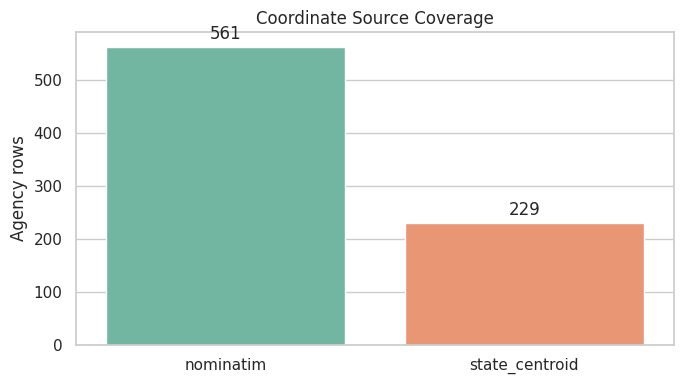

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
source_counts = geo["geocode_source"].value_counts().rename_axis("source").reset_index(name="rows")
sns.barplot(data=source_counts, x="source", y="rows", hue="source", palette="Set2", legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
ax.set_title("Coordinate Source Coverage")
ax.set_xlabel("")
ax.set_ylabel("Agency rows")
plt.tight_layout()

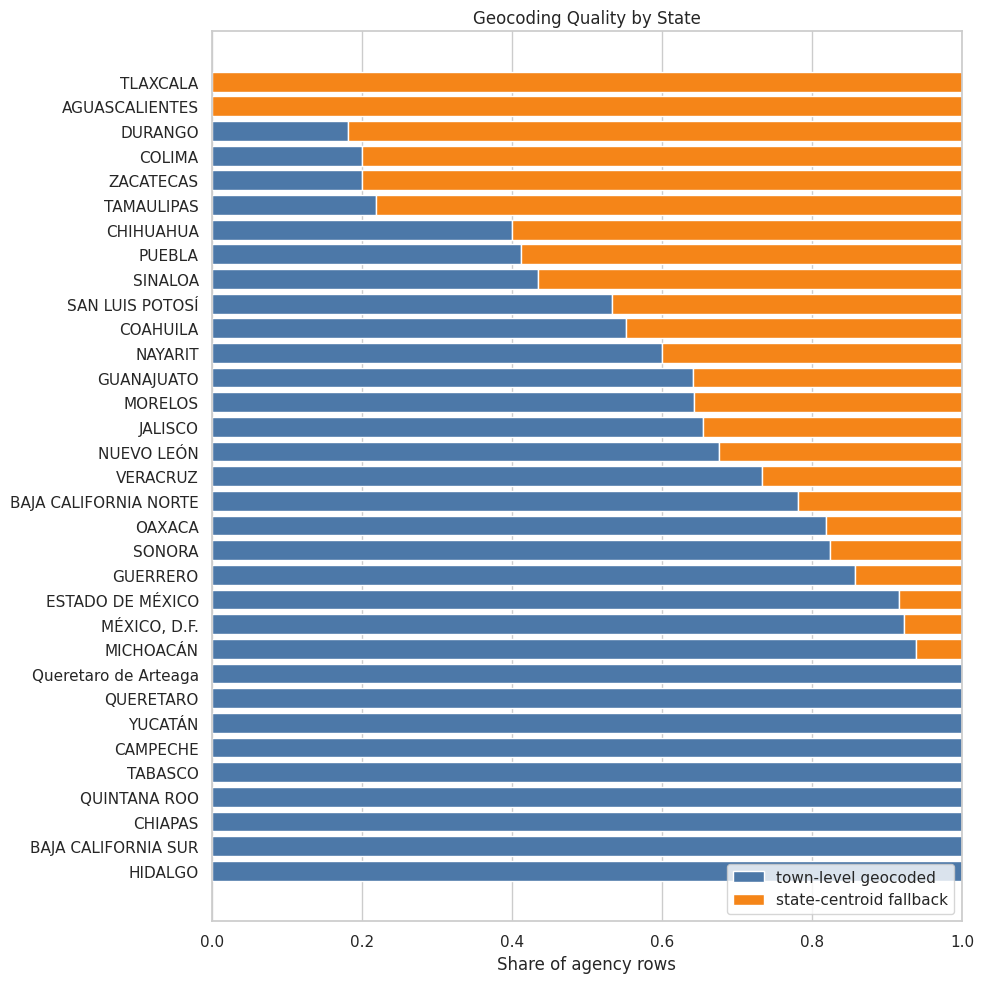

In [8]:
plot_state = quality_by_state.reset_index().sort_values("fallback_rate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(plot_state["State"], plot_state["town_geocoded_rate"], label="town-level geocoded", color="#4c78a8")
ax.barh(
    plot_state["State"],
    plot_state["fallback_rate"],
    left=plot_state["town_geocoded_rate"],
    label="state-centroid fallback",
    color="#f58518",
)
ax.set_xlim(0, 1)
ax.set_xlabel("Share of agency rows")
ax.set_ylabel("")
ax.set_title("Geocoding Quality by State")
ax.legend(loc="lower right")
plt.tight_layout()

In [9]:
needs_review = quality_by_state.query("fallback_rate > 0").copy()
needs_review.sort_values(["fallback_rate", "state_centroid_fallback"], ascending=[False, False]).head(15)

,agencies,town_geocoded,state_centroid_fallback,unique_clean_towns,town_geocoded_rate,fallback_rate
State,,,,,,
AGUASCALIENTES,7,0,7,2,0.000000,1.000000
TLAXCALA,6,0,6,1,0.000000,1.000000
DURANGO,11,2,9,3,0.181818,0.818182
COLIMA,10,2,8,3,0.200000,0.800000
ZACATECAS,10,2,8,3,0.200000,0.800000
TAMAULIPAS,32,7,25,8,0.218750,0.781250
CHIHUAHUA,25,10,15,9,0.400000,0.600000
PUEBLA,34,14,20,13,0.411765,0.588235
SINALOA,23,10,13,7,0.434783,0.565217


States at the top of the previous table are the places where the geospatial data is weakest. They are still represented, but many coordinates are approximate state centers rather than town-level points.

## 5. Geographic Shape of the Network

The first chart is a static longitude/latitude view, useful for notebooks and reports. The map below it is interactive.

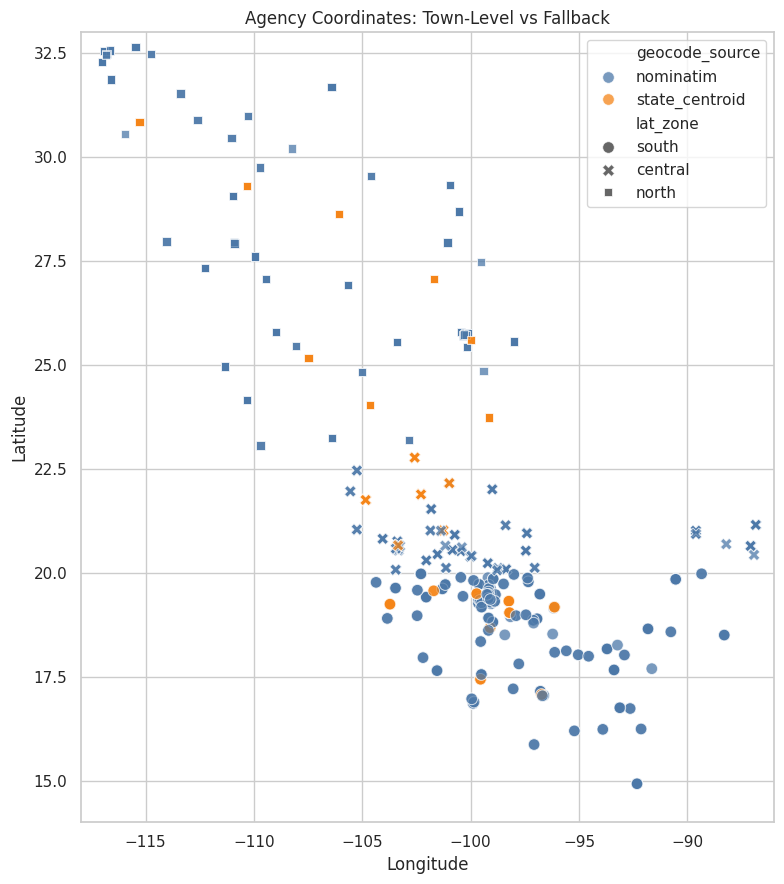

In [10]:
fig, ax = plt.subplots(figsize=(8, 9))
sns.scatterplot(
    data=geo,
    x="lon",
    y="lat",
    hue="geocode_source",
    style="lat_zone",
    palette={"nominatim": "#4c78a8", "state_centroid": "#f58518"},
    s=70,
    alpha=0.75,
    ax=ax,
)
ax.set_title("Agency Coordinates: Town-Level vs Fallback")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-118, -86)
ax.set_ylim(14, 33)
ax.legend(title="", loc="upper right")
plt.tight_layout()

In [11]:
center = [23.6, -102.5]
m = folium.Map(location=center, zoom_start=5, tiles="CartoDB positron")

colors = {"nominatim": "blue", "state_centroid": "orange"}
for source, group in geo.groupby("geocode_source", observed=True):
    feature_group = folium.FeatureGroup(name=f"{source} ({len(group)} agencies)", show=True)
    cluster = MarkerCluster(name=f"{source} clustered markers")
    for row in group.itertuples(index=False):
        popup = folium.Popup(
            html=(
                f"<b>Agency:</b> {row.Agencia_ID}<br>"
                f"<b>Raw town:</b> {row.Town}<br>"
                f"<b>Clean town:</b> {row.town_clean}<br>"
                f"<b>State:</b> {row.State}<br>"
                f"<b>Source:</b> {row.geocode_source}<br>"
                f"<b>Cluster:</b> {row.geo_cluster}<br>"
                f"<b>Distance to hub:</b> {row.dist_to_hub_km:.1f} km"
            ),
            max_width=320,
        )
        folium.CircleMarker(
            location=[row.lat, row.lon],
            radius=5 if source == "nominatim" else 7,
            color=colors.get(source, "gray"),
            fill=True,
            fill_opacity=0.75,
            popup=popup,
        ).add_to(cluster)
    cluster.add_to(feature_group)
    feature_group.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

## 6. Spatial Features for Modeling

These are the spatial features created for modeling: cluster, distance to Mexico City, and latitude zone. Clusters should be inspected visually before assigning business labels.

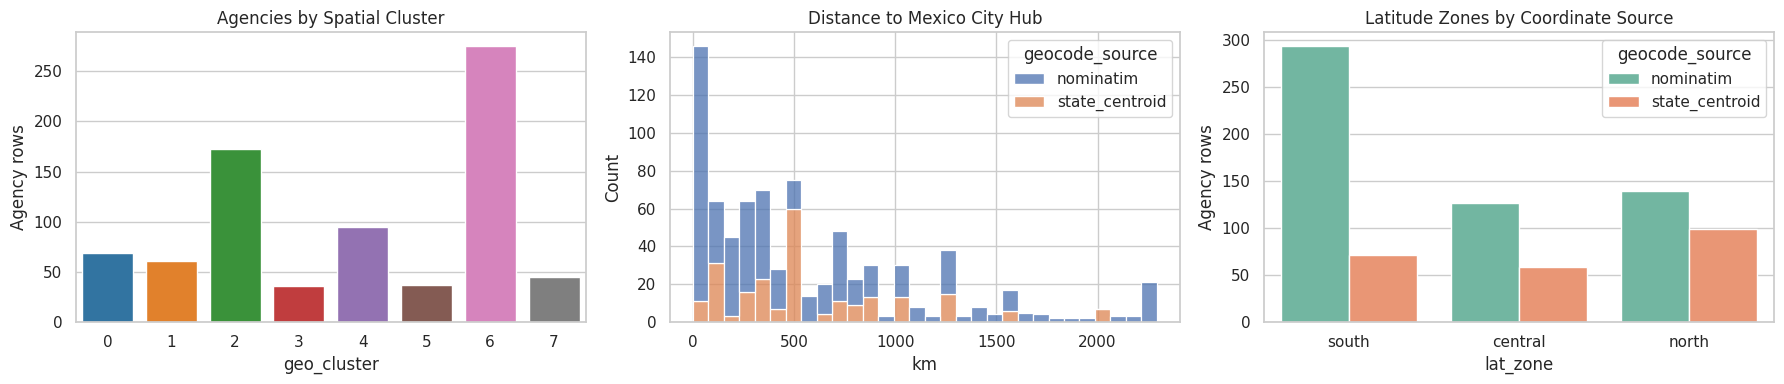

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=geo, x="geo_cluster", hue="geo_cluster", palette="tab10", legend=False, ax=axes[0])
axes[0].set_title("Agencies by Spatial Cluster")
axes[0].set_xlabel("geo_cluster")
axes[0].set_ylabel("Agency rows")

sns.histplot(data=geo, x="dist_to_hub_km", hue="geocode_source", bins=30, multiple="stack", ax=axes[1])
axes[1].set_title("Distance to Mexico City Hub")
axes[1].set_xlabel("km")

sns.countplot(data=geo, x="lat_zone", hue="geocode_source", palette="Set2", ax=axes[2])
axes[2].set_title("Latitude Zones by Coordinate Source")
axes[2].set_xlabel("lat_zone")
axes[2].set_ylabel("Agency rows")

plt.tight_layout()

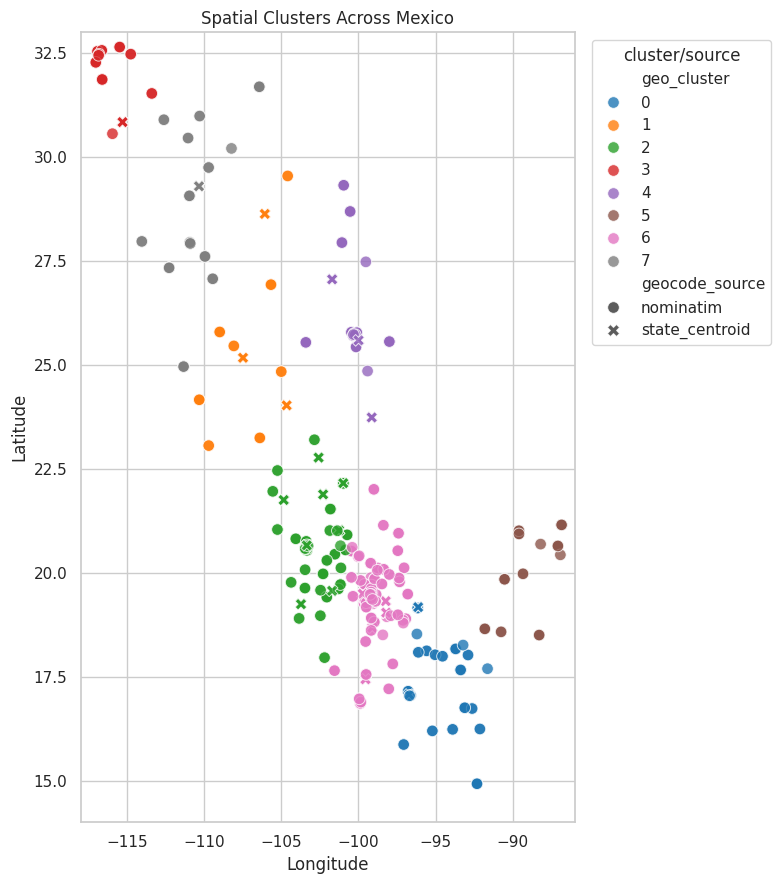

In [13]:
fig, ax = plt.subplots(figsize=(8, 9))
sns.scatterplot(
    data=geo,
    x="lon",
    y="lat",
    hue="geo_cluster",
    style="geocode_source",
    palette="tab10",
    s=70,
    alpha=0.8,
    ax=ax,
)
ax.set_title("Spatial Clusters Across Mexico")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-118, -86)
ax.set_ylim(14, 33)
ax.legend(title="cluster/source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 7. Where to Be Careful

Fallback coordinates create repeated points at state centers. That is expected, but it can visually exaggerate the importance of state capitals/centroids. Use `geocode_source` as a quality flag in later analysis.

In [14]:
fallback_examples = (
    geo.loc[geo["geocode_source"].eq("state_centroid"), ["Agencia_ID", "Town", "State", "town_clean", "geocode_query", "lat", "lon"]]
    .sort_values(["State", "town_clean", "Agencia_ID"])
)
fallback_examples.head(30)

,Agencia_ID,Town,State,town_clean,geocode_query,lat,lon
106,1347,2251 AGUASCALIENTES NORTE,AGUASCALIENTES,UASCALIENTES NORTE,"UASCALIENTES NORTE, AGUASCALIENTES, Mexico",21.8853,-102.2916
113,1355,2251 AGUASCALIENTES NORTE,AGUASCALIENTES,UASCALIENTES NORTE,"UASCALIENTES NORTE, AGUASCALIENTES, Mexico",21.8853,-102.2916
128,1374,2251 AGUASCALIENTES NORTE,AGUASCALIENTES,UASCALIENTES NORTE,"UASCALIENTES NORTE, AGUASCALIENTES, Mexico",21.8853,-102.2916
624,22519,2251 AGUASCALIENTES NORTE,AGUASCALIENTES,UASCALIENTES NORTE,"UASCALIENTES NORTE, AGUASCALIENTES, Mexico",21.8853,-102.2916
110,1351,2252 AGUASCALIENTES SIGLO XXI,AGUASCALIENTES,UASCALIENTES SIGLO XXI,"UASCALIENTES SIGLO XXI, AGUASCALIENTES, Mexico",21.8853,-102.2916
341,1974,2252 AGUASCALIENTES SIGLO XXI,AGUASCALIENTES,UASCALIENTES SIGLO XXI,"UASCALIENTES SIGLO XXI, AGUASCALIENTES, Mexico",21.8853,-102.2916
625,22529,2252 AGUASCALIENTES SIGLO XXI,AGUASCALIENTES,UASCALIENTES SIGLO XXI,"UASCALIENTES SIGLO XXI, AGUASCALIENTES, Mexico",21.8853,-102.2916
199,1524,2152 Cruce De Anden Noroeste,BAJA CALIFORNIA NORTE,Cruce De Anden Noroeste,"Cruce De Anden Noroeste, BAJA CALIFORNIA NORTE...",30.8406,-115.2838
217,1551,2573 TIJUANA GATO BRONCO,BAJA CALIFORNIA NORTE,TIJUANA GATO BRONCO,"TIJUANA GATO BRONCO, BAJA CALIFORNIA NORTE, Me...",30.8406,-115.2838
235,1583,2573 TIJUANA GATO BRONCO,BAJA CALIFORNIA NORTE,TIJUANA GATO BRONCO,"TIJUANA GATO BRONCO, BAJA CALIFORNIA NORTE, Me...",30.8406,-115.2838


In [15]:
duplicate_coordinate_groups = (
    geo.groupby(["lat", "lon", "geocode_source"], observed=True)
    .agg(
        agencies=("Agencia_ID", "count"),
        states=("State", lambda s: ", ".join(sorted(s.unique())[:4])),
        sample_towns=("town_clean", lambda s: ", ".join(sorted(s.unique())[:6])),
    )
    .query("agencies > 1")
    .sort_values("agencies", ascending=False)
)
duplicate_coordinate_groups.head(20)

,,,agencies,states,sample_towns
lat,lon,geocode_source,,,
23.736900,-99.141100,state_centroid,25,TAMAULIPAS,"MATAMOROS BIMBO, REYNOSA BIMBO, REYNOSA MARINE..."
19.041400,-98.206300,state_centroid,20,PUEBLA,"Cruce De Andén Sureste, PUEBLA NORTE BIMBO, PU..."
20.659700,-103.349600,state_centroid,19,JALISCO,"GRANJAS MARINELA, OCOTLAN BIMBO, PUERTO VALLAR..."
28.632000,-106.069100,state_centroid,15,CHIHUAHUA,"CHIHUAHUA BIMBO, CHIHUAHUA MARINELA, DELICIAS ..."
21.019000,-101.257400,state_centroid,14,GUANAJUATO,"CELAYA INDUSTRIAL WONDER, IRAPUATO SAN MIGUELI..."
25.172100,-107.479500,state_centroid,13,SINALOA,"BW GUASAVE, CULIACAN BIMBO, CULIACAN MARINELA,..."
27.058700,-101.706800,state_centroid,13,COAHUILA,"MONCLOVA BIMBO, SALTILLO BIMBO, SALTILLO MARINELA"
19.173800,-96.134200,state_centroid,12,VERACRUZ,"COATZACOALCOS MLA, CONVENIENCIA VERACRUZ SUR, ..."
25.592200,-99.996200,state_centroid,11,NUEVO LEÓN,"Cruce De Anden Norte, HIDALGO BIMBO, SANTA CAT..."


## 8. Takeaways

After running the cells above, use these statements to guide modeling decisions:

- We have one geospatial row per agency, so the table can be joined to train/test by `Agencia_ID`.
- Most agencies have usable coordinates, but not all coordinates are equally trustworthy.
- `nominatim` rows are the strongest location signal because they are town-level matches.
- `state_centroid` rows preserve broad regional information but lose within-state precision.
- States with high fallback rates should be reviewed before making fine-grained maps or distance-based conclusions.
- For modeling, keep `geocode_source` or a fallback flag so the model can distinguish precise and approximate coordinates.